# 3 Dominio Espacial

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

def show_image(image, title=None):
    """Display an image using matplotlib."""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

In [2]:
def filtro_gris(img, mask, uint8=True):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h1, w1 = img.shape
    h2, w2 = mask.shape
    
    g = np.zeros_like(img, dtype=np.float32)
    for y in range(w1):
        for x in range(h1):
            valor = 0
            s = -h2 // 2
            for j in range(w2):
                t = -w2 // 2
                for i in range(h2):
                    if 0 <= y+t < w1 and 0 <= x+s < h1:
                        valor += mask[i, j] * img[x+s, y+t]
                    t += 1
                s += 1
            g[x, y] = valor
    if uint8:
        return np.clip(g, 0, 255).astype(np.uint8)
    else:
        return np.clip(g, 0, 255)

In [3]:
def filtro_color(img, mask):
    h1, w1, ch = img.shape
    h2, w2 = mask.shape
    
    g = np.zeros_like(img, dtype=np.float32)
    for c in range(ch):  # Procesar cada canal por separado
        for y in range(w1):
            for x in range(h1):
                valor = 0
                s = -h2 // 2
                for j in range(w2):
                    t = -w2 // 2
                    for i in range(h2):
                        if 0 <= y+t < w1 and 0 <= x+s < h1:
                            valor += mask[i, j] * img[x+s, y+t, c]
                        t += 1
                    s += 1
                g[x, y, c] = valor
    return np.clip(g, 0, 255).astype(np.uint8)

**1. Filtro de Media: Implementar un filtro de media en una imagen usando convoluci´on con un kernel
de promediado.**

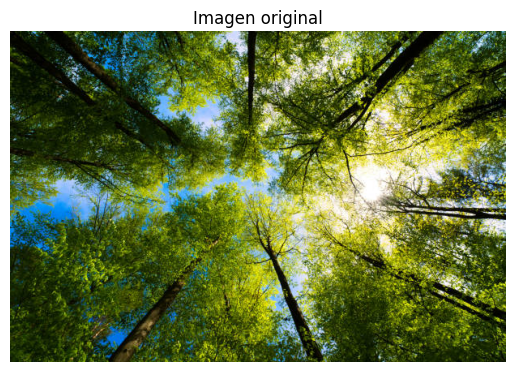

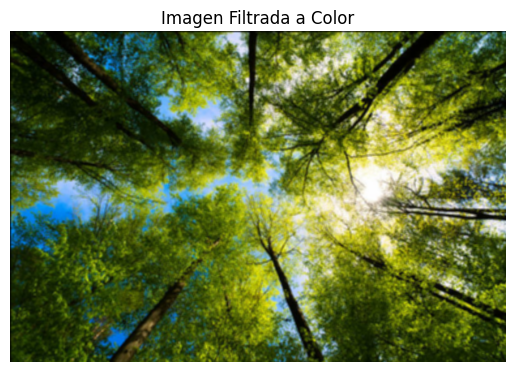

In [4]:
img = cv2.imread('bosque.jpg')
mask = np.ones((3, 3), dtype=np.float32) / 9
filtered = filtro_color(img, mask)

show_image(img, "Imagen original")
show_image(filtered, "Imagen Filtrada a Color")



**2. Filtro de Mediana: Aplicar un filtro de mediana para reducir el ruido en una imagen.**

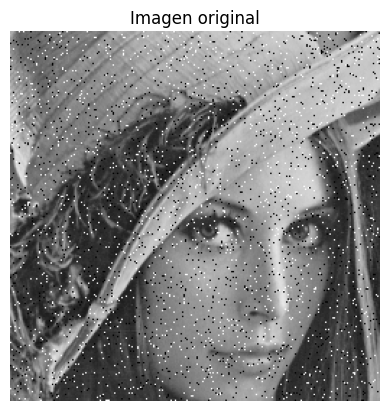

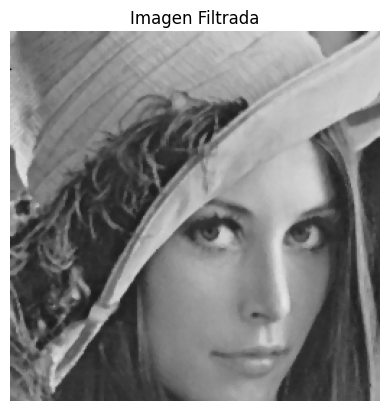

In [5]:
def filtro_mediana(img, size=(3,3)):
    h1, w1, ch = img.shape
    h2,w2 = size
    if h2 % 2 == 0 or w2 % 2 == 0:
        raise ValueError("El tamaño del filtro debe ser impar.")
    
    if h2 > h1 or w2 > w1:
        raise ValueError("El tamaño del filtro no puede ser mayor que la imagen.")
    
    g = np.zeros_like(img, dtype=np.float32)
    for y in range(w1):
        for x in range(h1):
            valores = []
            s = -h2 // 2
            for j in range(w2):
                t = -w2 // 2
                for i in range(h2):
                    if 0 <= y+t < w1 and 0 <= x+s < h1:
                        valores.append(img[x+s, y+t])
                    t += 1
                s += 1
            valor = np.median(valores)
            g[x, y] = valor
    return np.clip(g, 0, 255).astype(np.uint8)

img = cv2.imread('salt_peper.png')
filtered = filtro_mediana(img)
show_image(img, "Imagen original")
show_image(filtered, "Imagen Filtrada")

**3. Filtro Gaussiano: Aplicar un filtro gaussiano para suavizar una imagen y analizar su efecto en los
bordes.**  

Se observan los bordes más difuminados, se pierden los detalles finos de la imagen.

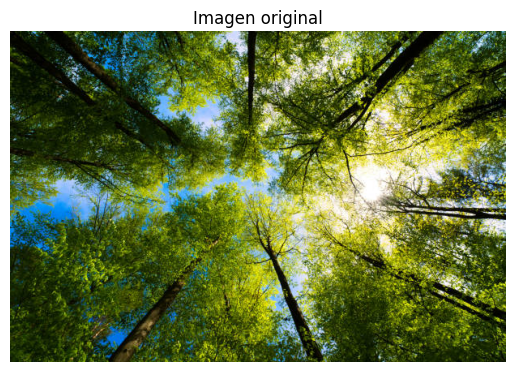

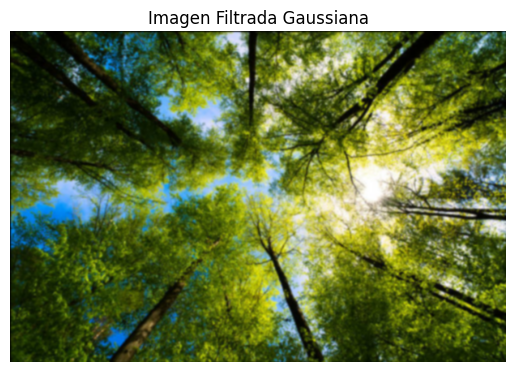

In [6]:
def kernel_gaussiano(size, sigma):
    k = size // 2
    x, y = np.meshgrid(np.arange(-k, k+1), np.arange(-k, k+1))
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    kernel /= np.sum(kernel)  # Normalizamos para que sume 1
    return kernel

def filtro_gaussiano(img, size=3, sigma=1):
    h1, w1 = img.shape
    h2 = size
    w2 = size
    mask = kernel_gaussiano(size, sigma)
    if h2 % 2 == 0 or w2 % 2 == 0:
        raise ValueError("El tamaño del filtro debe ser impar.")
    
    if h2 > h1 or w2 > w1:
        raise ValueError("El tamaño del filtro no puede ser mayor que la imagen.")
    
    g = np.zeros_like(img, dtype=np.float32)
    for y in range(w1):
        for x in range(h1):
            valor = 0
            s = -h2 // 2
            for j in range(w2):
                t = -w2 // 2
                for i in range(h2):
                    if 0 <= y+t < w1 and 0 <= x+s < h1:
                        valor += mask[i,j] * img[x+s, y+t]
                    t += 1
                s += 1
            g[x, y] = valor
    return np.clip(g, 0, 255).astype(np.uint8)

img = cv2.imread('bosque.jpg')
mask = kernel_gaussiano(5, 1)
filtered = filtro_color(img, mask)
show_image(img, "Imagen original")
show_image(filtered, "Imagen Filtrada Gaussiana")

**4. Filtro Laplaciano: Aplicar el operador de Laplace para detectar bordes en una imagen en escala de
grises.**

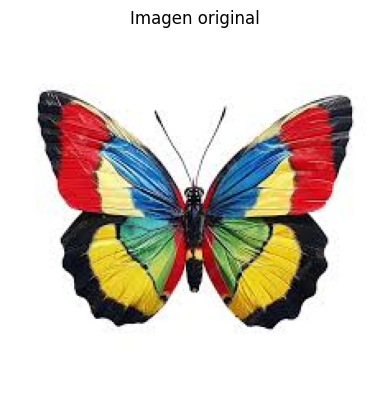

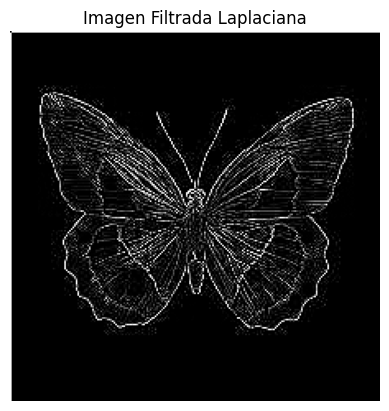

In [7]:
img = cv2.imread('mariposa.jpg')
#laplaciano
def laplace_filter(img):
    mask = np.array([[0, 1, 0],[1, -4, 1],[0, 1, 0]], dtype=np.float32)
    return filtro_gris(img, mask)

filtered = laplace_filter(img)
show_image(img, "Imagen original")
show_image(filtered, "Imagen Filtrada Laplaciana")

**5. Filtro de Sobel: Calcular el gradiente de una imagen usando los filtros de Sobel en las direcciones X
e Y.**

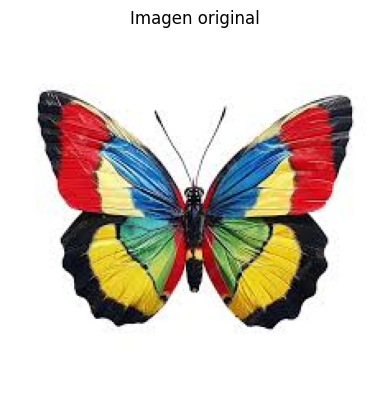

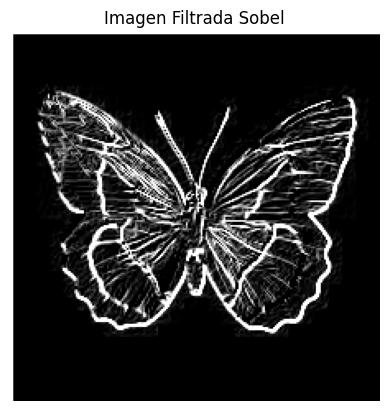

In [8]:
img = cv2.imread('mariposa.jpg')
def sobel_filter(img):
    sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    filtered_x = filtro_gris(img, sobel_x, uint8=False)
    filtered_y = filtro_gris(img, sobel_y, uint8=False)
    filtered = np.sqrt(filtered_x**2 + filtered_y**2)
    filtered = np.clip(filtered, 0, 255).astype(np.uint8)
    return filtered
filtered = sobel_filter(img)
show_image(img, "Imagen original")
show_image(filtered, "Imagen Filtrada Sobel")

**6. Filtro de Scharr: Comparar el resultado del filtro de Sobel con el filtro de Scharr.**

**7. Filtro de Prewitt: Aplicar el operador de Prewitt y comparar con Sobel.**

**8. Suavizado y Sobel (*): Aplicar un filtro gaussiano antes del operador de Sobel y analizar las diferencias
en la detecci´on de bordes.**  

Ahora el filtro Sobel muestra los bordes de forma menos nítida, perdiendo algunos detalles de bordes más finos o reflejos en la imagen.

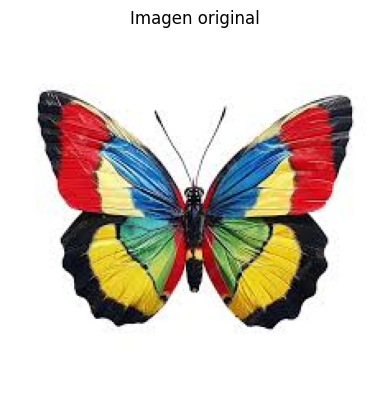

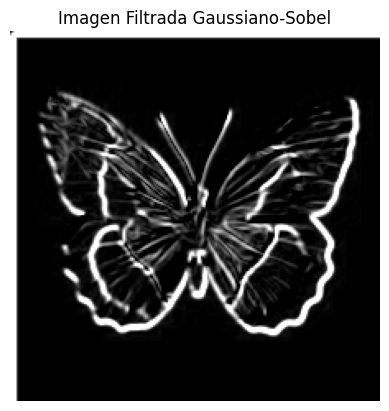

In [9]:
img = cv2.imread('mariposa.jpg')

#filtro gaussiano
mask = kernel_gaussiano(5, 1)
gaussiano = filtro_color(img, mask)

# filtro sobel
filtered = sobel_filter(gaussiano)


show_image(img, "Imagen original")
show_image(filtered, "Imagen Filtrada Gaussiano-Sobel")

**9. Filtro Laplaciano del Gaussiano (LoG): Aplicar un filtro gaussiano seguido de un operador de Laplace
para detectar bordes.**

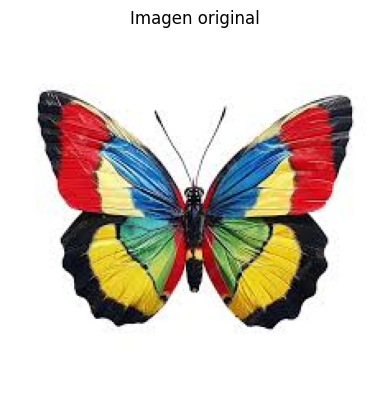

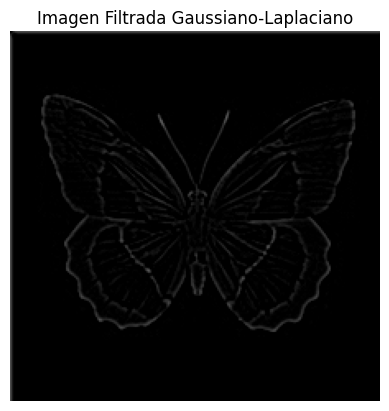

In [10]:
img = cv2.imread('mariposa.jpg')

#filtro gaussiano
mask = kernel_gaussiano(5, 1)
gaussiano = filtro_color(img, mask)

#laplaciano
mask = np.array([[0, 1, 0],[1, -4, 1],[0, 1, 0]], dtype=np.float32)
filtered = filtro_gris(gaussiano, mask)

show_image(img, "Imagen original")
show_image(filtered, "Imagen Filtrada Gaussiano-Laplaciano")


**10. Filtro de Paso Alto Personalizado: Implementar un filtro de realce de bordes con una matriz de convolución personalizada.**

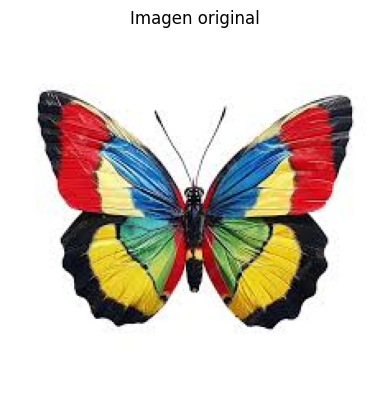

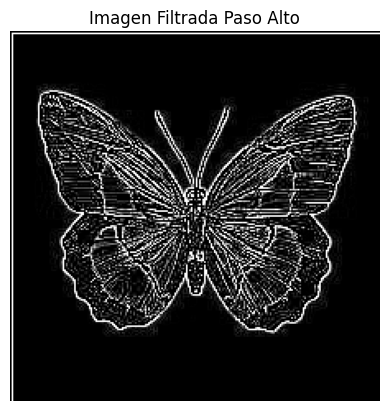

In [11]:
img = cv2.imread('mariposa.jpg')

kernel_paso_alto = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

filtered = filtro_gris(img, kernel_paso_alto)
show_image(img, "Imagen original")
show_image(filtered, "Imagen Filtrada Paso Alto")

**11. Filtro Canny: Aplicar el detector de bordes de Canny y ajustar los umbrales para obtener diferentes
resultados.**

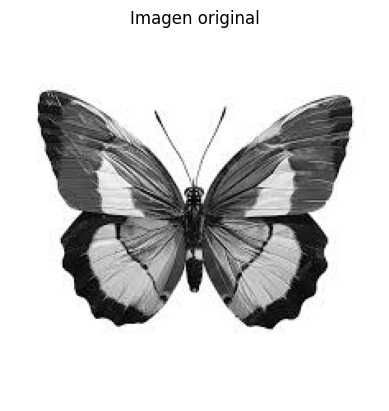

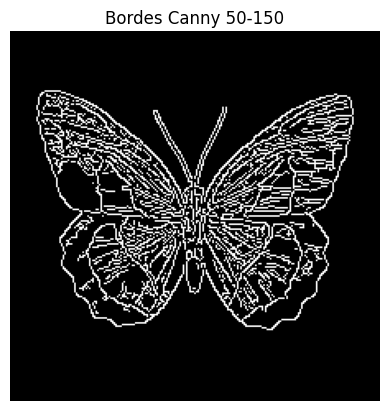

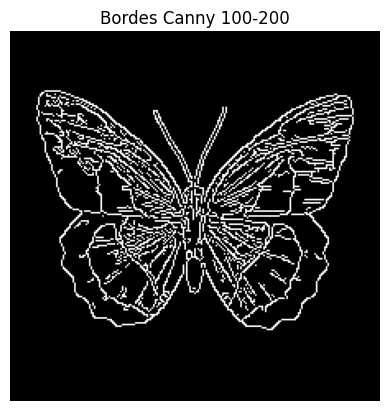

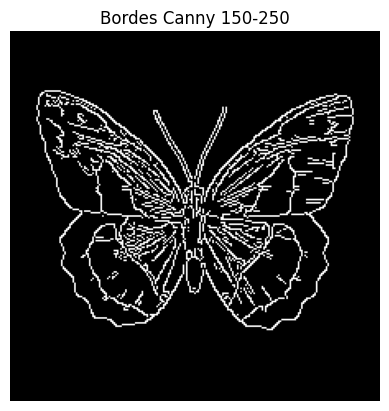

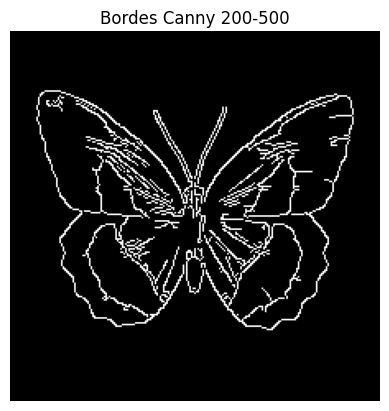

In [12]:
img = cv2.imread('mariposa.jpg', cv2.IMREAD_GRAYSCALE)
bordes1 = cv2.Canny(img, threshold1=50, threshold2=150)
bordes2 = cv2.Canny(img, threshold1=100, threshold2=200)
bordes3 = cv2.Canny(img, threshold1=150, threshold2=250)
bordes4 = cv2.Canny(img, threshold1=200, threshold2=500)

show_image(img, "Imagen original")
show_image(bordes1, "Bordes Canny 50-150")
show_image(bordes2, "Bordes Canny 100-200")
show_image(bordes3, "Bordes Canny 150-250")
show_image(bordes4, "Bordes Canny 200-500")

**12. (*) Comparación de Métodos de Detección de Bordes : Comparar Sobel, Prewitt, Laplace y Canny trabajando diversas imágenes con características diferentes.**  
Se observa que los filtros Sobel y Prewitt son bastante similares, aunque se nota cómo Sobel enfatiza los bordes izquierdos de las figuras en las imágenes y Prewitt hace algo similar con los bordes derechos. En imágenes con muchos detalles como la del bosque, Sobel y Prewitt devuelven un resultado difícil de visualizar, al igual que el resto de los filtros. Laplace y Canny en imágenes más simples detallan con claridad los bordes, distinguiendose en que Laplace muestra detalles mas finos o delicados de la imagen y Canny resalta con un trazo grueso los detalles. Para la imagen del elefante Canny muestra satisfactoriamente el detalle de la figura, mientras que Laplace devuelve una imagen oscura con pocos detalles, suponemos que puede tener que ver con el poco contraste entre colores de la imagen; en la imagen del bosque Laplace resulta devolver la imagen más distinguible, mientras que Canny pierde detalles más finos y no permite comprenderla.

In [13]:
def prewitt_filter(img):
    kernel_x = np.array([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]], dtype=np.float32)
    

    kernel_y = np.array([[ 1,  1,  1],
                        [ 0,  0,  0],
                        [-1, -1, -1]], dtype=np.float32)

    filtered_x = filtro_gris(img, kernel_x, uint8=False)
    filtered_y = filtro_gris(img, kernel_y, uint8=False)
    filtered = np.sqrt(filtered_x**2 + filtered_y**2)
    return np.clip(filtered, 0, 255).astype(np.uint8)

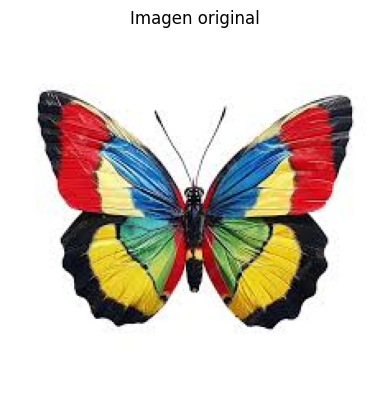

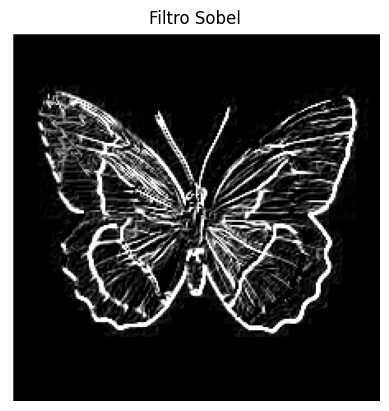

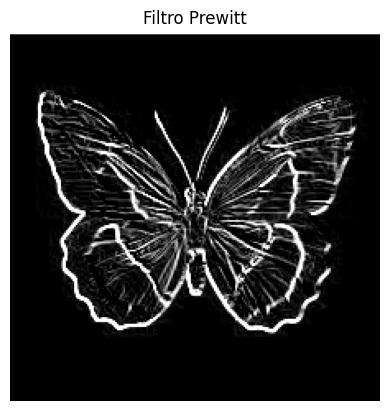

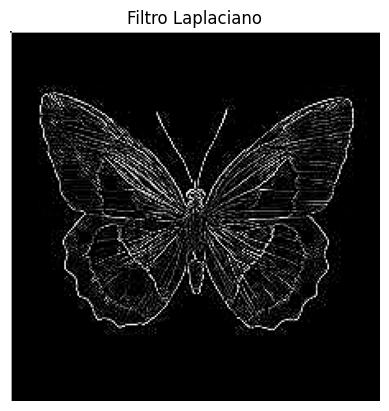

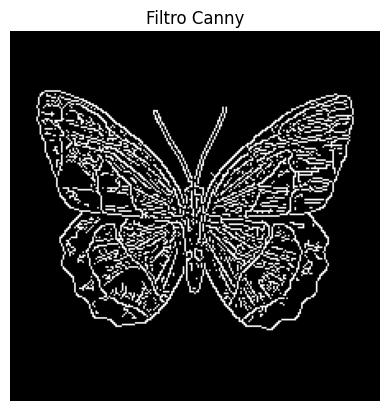

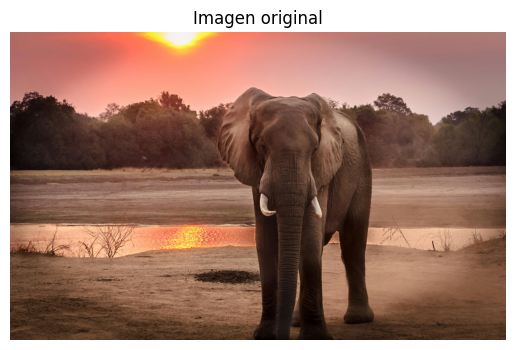

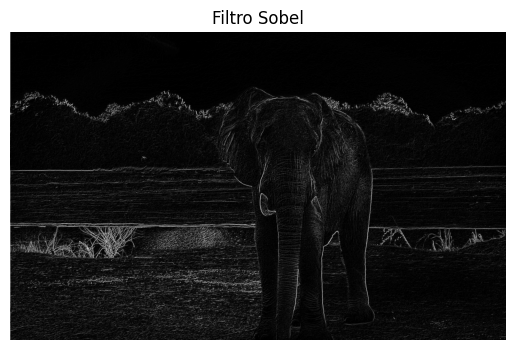

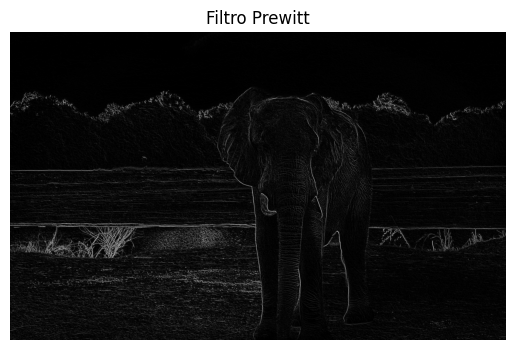

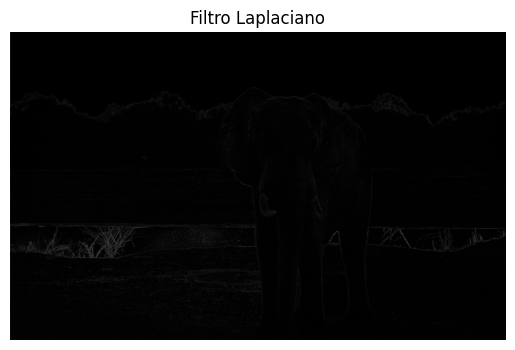

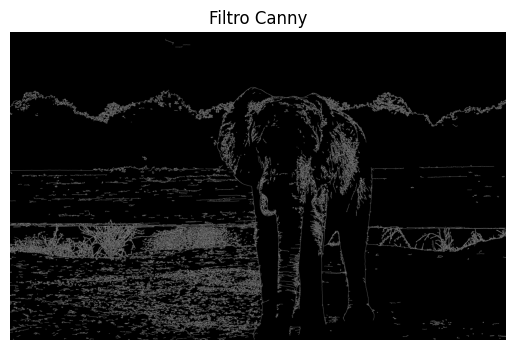

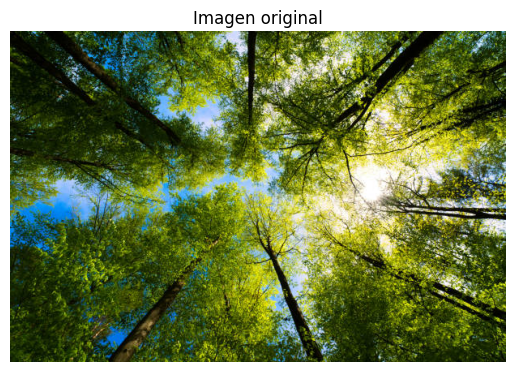

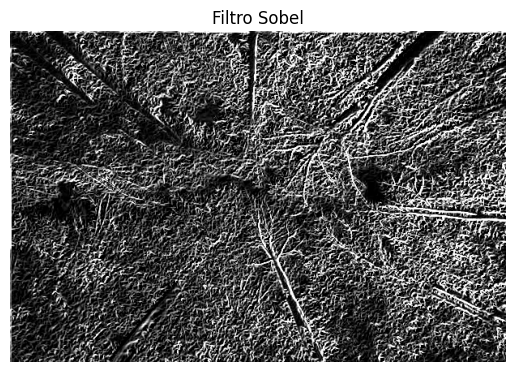

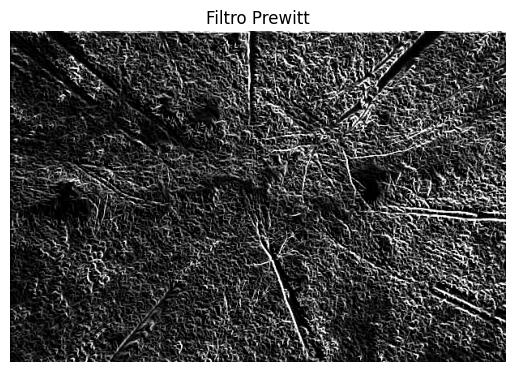

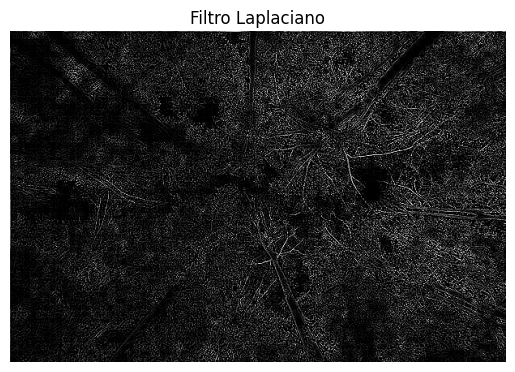

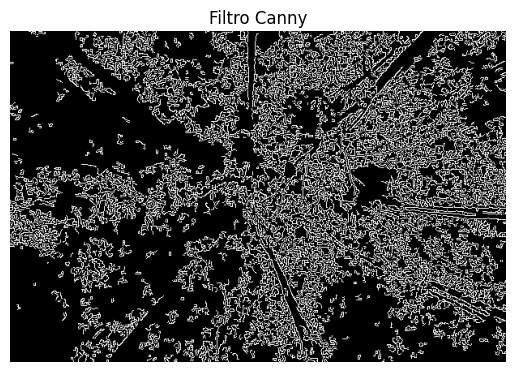

In [15]:
img1 = cv2.imread('mariposa.jpg')
img2 = cv2.imread('elefante.jpg')
img3 = cv2.imread('bosque.jpg')

sobel_filtered_1 = sobel_filter(img1)
prewitt_filtered_1 = prewitt_filter(img1)
laplacian_filtered_1 = laplace_filter(img1)
canny_filtered_1 = cv2.Canny(img1, threshold1=50, threshold2=150)

sobel_filtered_2 = sobel_filter(img2)
prewitt_filtered_2 = prewitt_filter(img2)
laplacian_filtered_2 = laplace_filter(img2)
canny_filtered_2 = cv2.Canny(img2, threshold1=50, threshold2=150)

sobel_filtered_3 = sobel_filter(img3)
prewitt_filtered_3 = prewitt_filter(img3)
laplacian_filtered_3 = laplace_filter(img3)
canny_filtered_3 = cv2.Canny(img3, threshold1=200, threshold2=500)


show_image(img1, "Imagen original")
show_image(sobel_filtered_1, "Filtro Sobel")
show_image(prewitt_filtered_1, "Filtro Prewitt")
show_image(laplacian_filtered_1, "Filtro Laplaciano")
show_image(canny_filtered_1, "Filtro Canny")

show_image(img2, "Imagen original")
show_image(sobel_filtered_2, "Filtro Sobel")
show_image(prewitt_filtered_2, "Filtro Prewitt")
show_image(laplacian_filtered_2, "Filtro Laplaciano")
show_image(canny_filtered_2, "Filtro Canny")

show_image(img3, "Imagen original")
show_image(sobel_filtered_3, "Filtro Sobel")
show_image(prewitt_filtered_3, "Filtro Prewitt")
show_image(laplacian_filtered_3, "Filtro Laplaciano")
show_image(canny_filtered_3, "Filtro Canny")



**13. (*) Realce de Detalles: Aplicar un filtro de paso alto y sumarlo a la imagen original para mejorar los
detalles.**

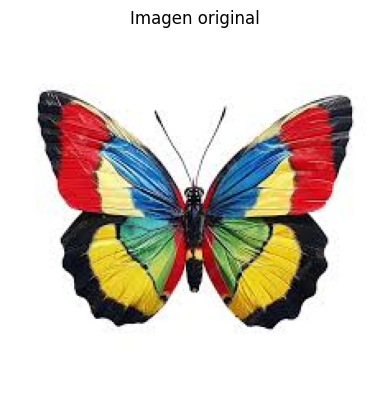

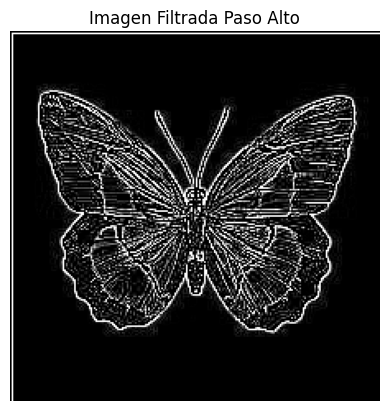

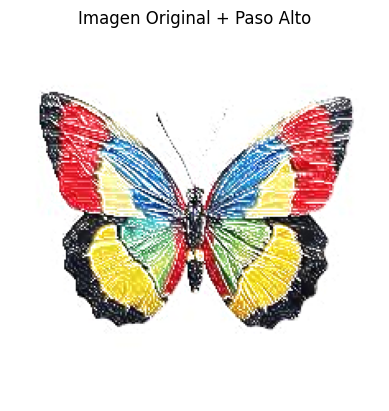

In [23]:
img = cv2.imread('mariposa.jpg')

kernel_paso_alto = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

filtered = filtro_gris(img, kernel_paso_alto)

filtered = cv2.resize(filtered, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)

filtered_color = cv2.cvtColor(filtered, cv2.COLOR_GRAY2BGR)
#filtered_color = cv2.bitwise_not(filtered_color)

sum_imgs = cv2.add(img, filtered_color)

show_image(img, "Imagen original")
show_image(filtered_color, "Imagen Filtrada Paso Alto")
show_image(sum_imgs, "Imagen Original + Paso Alto")

**14. Reducci´on de Ruido con Bilateral Filter: Aplicar un filtro bilateral para suavizar la imagen sin perder
detalles importantes.**

**15. (*) Filtro de Diferencia Gaussiana (DoG): Aplicar la t´ecnica de Diferencia de Gaussiana para resaltar
bordes.**

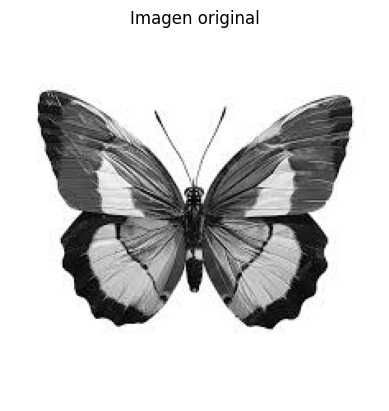

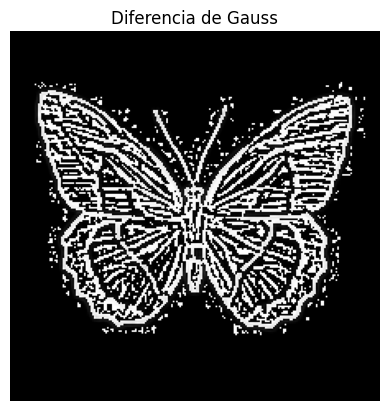

In [24]:
img = cv2.imread('mariposa.jpg', cv2.IMREAD_GRAYSCALE)

# Aplicar suavizado gaussiano con dos sigma diferentes
gauss1 = cv2.GaussianBlur(img, (5, 5), 1)
gauss2 = cv2.GaussianBlur(img, (5, 5), 2)

# Diferencia de Gauss
dog = gauss1 - gauss2

show_image(img, "Imagen original")
show_image(dog, "Diferencia de Gauss")